### Quang

In [3]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.7 MB/s eta 0:00:00


In [6]:
from typing import Tuple, Union
import numpy as np


class Qang:
    """
    Unidad Qang (qg):
      - Polar (qg_Z): Sesgo z en [-1.0, 1.0]. Corresponde a P(|0>) - P(|1>) = cos(theta).
      - Entrópico (qg_S): Entropía de Shannon de la medición z en [0.0, 1.0].
    """

    def __init__(self, value: float, mode: str = "polar"):
        self.mode = mode.lower()
        if self.mode == "polar":
            if not (-1.0 <= value <= 1.0):
                raise ValueError("qg_Z polar debe estar en el intervalo [-1.0, 1.0].")
            self._value = float(value)
        elif self.mode == "entropic":
            if not (0.0 <= value <= 1.0):
                raise ValueError("qg_S entrópico debe estar en el intervalo [0.0, 1.0].")
            self._value = float(value)
        else:
            raise ValueError("Modo no reconocido. Usa 'polar' o 'entropic'.")

    @property
    def value(self) -> float:
        return self._value

    # =========================================================================
    # Creación a partir de ÁNGULOS
    # =========================================================================
    @classmethod
    def from_angle(
        cls,
        angle: float,
        unit: str = "rad",
        mode: str = "polar"
    ) -> "Qang":
        """
        Crea un Qang a partir de un ángulo polar theta.

        Args:
            angle: Valor del ángulo theta (0 <= theta <= pi rad / 180°).
            unit: 'rad' para radianes o 'deg' para grados.
            mode: 'polar' o 'entropic'.
        """
        theta = np.deg2rad(angle) if unit.lower() in ("deg", "degrees", "grados") else float(angle)

        if mode == "polar":
            # qg_Z = cos(theta)
            return cls(float(np.cos(theta)), mode="polar")

        elif mode == "entropic":
            # qg_S = -P0*log2(P0) - P1*log2(P1)
            p0 = np.cos(theta / 2.0) ** 2
            p1 = np.sin(theta / 2.0) ** 2
            eps = 1e-15
            p0_safe = np.clip(p0, eps, 1.0 - eps)
            p1_safe = np.clip(p1, eps, 1.0 - eps)
            entropy = -p0_safe * np.log2(p0_safe) - p1_safe * np.log2(p1_safe)
            return cls(float(entropy), mode="entropic")

        raise ValueError("Modo no reconocido. Usa 'polar' o 'entropic'.")

    # =========================================================================
    # Creación a partir de PROBABILIDADES
    # =========================================================================
    @classmethod
    def from_probability(
        cls,
        p0: float,
        p1: Union[float, None] = None,
        mode: str = "polar"
    ) -> "Qang":
        """
        Crea un Qang a partir de la probabilidad de los estados de la base computacional.

        Args:
            p0: Probabilidad de medir |0> (0.0 <= p0 <= 1.0).
            p1: Probabilidad de medir |1> (opcional, si es None se asume 1 - p0).
            mode: 'polar' o 'entropic'.
        """
        if not (0.0 <= p0 <= 1.0):
            raise ValueError(f"p0 debe estar en [0, 1]. Recibido: {p0}")

        if p1 is None:
            p1 = 1.0 - p0
        else:
            if not (0.0 <= p1 <= 1.0):
                raise ValueError(f"p1 debe estar en [0, 1]. Recibido: {p1}")
            if not np.isclose(p0 + p1, 1.0, atol=1e-4):
                raise ValueError(f"Las probabilidades deben sumar 1. Suma: {p0 + p1}")

        if mode == "polar":
            # qg_Z = P(|0>) - P(|1>)
            return cls(float(p0 - p1), mode="polar")

        elif mode == "entropic":
            eps = 1e-15
            p0_safe = np.clip(p0, eps, 1.0 - eps)
            p1_safe = np.clip(p1, eps, 1.0 - eps)
            entropy = -p0_safe * np.log2(p0_safe) - p1_safe * np.log2(p1_safe)
            return cls(float(entropy), mode="entropic")

        raise ValueError("Modo no reconocido. Usa 'polar' o 'entropic'.")

    # =========================================================================
    # Métodos de Conversión y Salida
    # =========================================================================
    def to_angle(self, unit: str = "rad") -> float:
        """Devuelve el ángulo theta correspondiente."""
        if self.mode != "polar":
            raise NotImplementedError("La conversión de qg_S a ángulo es bivalente; usa 'polar'.")
        theta_rad = float(np.arccos(self._value))
        return float(np.rad2deg(theta_rad)) if unit.lower() in ("deg", "degrees", "grados") else theta_rad

    def to_probabilities(self) -> Tuple[float, float]:
        """Devuelve las probabilidades teóricas (P(|0>), P(|1>))."""
        if self.mode != "polar":
            raise NotImplementedError("Conversión unívoca a probabilidades solo en modo 'polar'.")
        p0 = (1.0 + self._value) / 2.0
        p1 = (1.0 - self._value) / 2.0
        return float(p0), float(p1)

    def __repr__(self) -> str:
        symbol = "qg_Z" if self.mode == "polar" else "qg_S"
        return f"{self._value:+.4f} {symbol}"


# =============================================================================
# Demostración / Pruebas
# =============================================================================
if __name__ == "__main__":
    print("=== 1. CREACIÓN DESDE ÁNGULOS ===")
    # Desde ángulo en radianes: theta = pi/3 (60°)
    qg_desde_rad = Qang.from_angle(np.pi / 3, unit="rad", mode="polar")
    print(f"Theta = pi/3 rad  ->  {qg_desde_rad}")

    # Desde ángulo en grados: theta = 90° (superposición equitativa |+>)
    qg_desde_deg = Qang.from_angle(90.0, unit="deg", mode="polar")
    print(f"Theta = 90 deg    ->  {qg_desde_deg}")

    # Modo entrópico desde ángulo: theta = 90° tiene entropía máxima (1 bit)
    qg_s_desde_deg = Qang.from_angle(90.0, unit="deg", mode="entropic")
    print(f"Theta = 90 deg (S)->  {qg_s_desde_deg}")

    print("\n=== 2. CREACIÓN DESDE PROBABILIDADES ===")
    # Dando solo P(|0>) = 0.85 (calcula P(|1>) = 0.15 automáticamente)
    qg_prob1 = Qang.from_probability(p0=0.85, mode="polar")
    print(f"P(|0>)=0.85       ->  {qg_prob1}")

    # Dando ambas probabilidades explícitas
    qg_prob2 = Qang.from_probability(p0=0.20, p1=0.80, mode="polar")
    print(f"P(|0>)=0.2, P=0.8 ->  {qg_prob2}")

    print("\n=== 3. REVERSIBILIDAD (RECONSTRUCCIÓN) ===")
    theta_recuperado_deg = qg_prob1.to_angle(unit="deg")
    p0_rec, p1_rec = qg_prob1.to_probabilities()
    print(f"Desde {qg_prob1}:")
    print(f"  - Ángulo theta : {theta_recuperado_deg:.2f}°")
    print(f"  - P(|0>), P(|1>): ({p0_rec:.3f}, {p1_rec:.3f})")

=== 1. CREACIÓN DESDE ÁNGULOS ===
Theta = pi/3 rad  ->  +0.5000 qg_Z
Theta = 90 deg    ->  +0.0000 qg_Z
Theta = 90 deg (S)->  +1.0000 qg_S

=== 2. CREACIÓN DESDE PROBABILIDADES ===
P(|0>)=0.85       ->  +0.7000 qg_Z
P(|0>)=0.2, P=0.8 ->  -0.6000 qg_Z

=== 3. REVERSIBILIDAD (RECONSTRUCCIÓN) ===
Desde +0.7000 qg_Z:
  - Ángulo theta : 45.57°
  - P(|0>), P(|1>): (0.850, 0.150)


In [5]:
from typing import Tuple, Union
import numpy as np
from qiskit import transpile
from qiskit.circuit import Gate, QuantumCircuit
from qiskit.circuit.library import RYGate


class Qang:
    """Clase para representar y convertir la unidad qang (qg)."""

    def __init__(self, value: float, mode: str = "polar"):
        self.mode = mode.lower()
        if self.mode == "polar":
            if not (-1.0 <= value <= 1.0):
                raise ValueError("El valor de qg_Z polar debe estar en el intervalo [-1.0, 1.0].")
            self._value = float(value)
        elif self.mode == "entropic":
            if not (0.0 <= value <= 1.0):
                raise ValueError("El valor de qg_S entrópico debe estar en el intervalo [0.0, 1.0].")
            self._value = float(value)
        else:
            raise ValueError("Modo no reconocido. Use 'polar' o 'entropic'.")

    @property
    def value(self) -> float:
        return self._value

    @classmethod
    def from_theta(cls, theta: float, mode: str = "polar") -> "Qang":
        if mode == "polar":
            return cls(float(np.cos(theta)), mode="polar")
        elif mode == "entropic":
            p0 = np.cos(theta / 2.0) ** 2
            p1 = np.sin(theta / 2.0) ** 2
            eps = 1e-15
            p0_safe = np.clip(p0, eps, 1.0 - eps)
            p1_safe = np.clip(p1, eps, 1.0 - eps)
            entropy = -p0_safe * np.log2(p0_safe) - p1_safe * np.log2(p1_safe)
            return cls(float(entropy), mode="entropic")
        raise ValueError("Modo no reconocido.")

    @classmethod
    def from_probabilities(cls, p0: float, p1: float) -> "Qang":
        if not np.isclose(p0 + p1, 1.0, atol=1e-4):
            raise ValueError(f"Las probabilidades deben sumar 1 (obtenido: {p0 + p1}).")
        return cls(float(p0 - p1), mode="polar")

    def to_theta(self) -> float:
        if self.mode == "polar":
            return float(np.arccos(self._value))
        raise NotImplementedError("La inversión de qg_S a theta es bivalente; use modo 'polar'.")

    def to_probabilities(self) -> Tuple[float, float]:
        if self.mode == "polar":
            p0 = (1.0 + self._value) / 2.0
            p1 = (1.0 - self._value) / 2.0
            return float(p0), float(p1)
        raise NotImplementedError("Conversión unívoca solo disponible para modo polar.")

    def __repr__(self) -> str:
        symbol = "qg_Z" if self.mode == "polar" else "qg_S"
        return f"{self._value:.4f} {symbol}"


class RQangGate(Gate):
    """Compuerta que rota un qubit según el valor polar qg_Z."""

    def __init__(self, qang_val: Union[float, Qang], label: str = "RQang"):
        if isinstance(qang_val, Qang):
            qg = qang_val
        else:
            qg = Qang(qang_val, mode="polar")

        self._theta = qg.to_theta()
        super().__init__(name="rqang", num_qubits=1, params=[qg.value], label=label)

    def _define(self):
        # Descompone internamente en RYGate
        qc = QuantumCircuit(1, name=self.name)
        qc.append(RYGate(self._theta), [0])
        self.definition = qc


if __name__ == "__main__":
    from qiskit_aer import AerSimulator

    # 1. Definir objetivo
    qg_objetivo = Qang(0.5, mode="polar")
    print(f"Instancia creada: {qg_objetivo}")
    print(f"Ángulo equivalente theta: {qg_objetivo.to_theta():.4f} rad")
    print(f"Probabilidades esperadas: {qg_objetivo.to_probabilities()}")

    # 2. Circuito
    qc = QuantumCircuit(1, 1)
    qc.append(RQangGate(qg_objetivo), [0])
    qc.measure(0, 0)

    print("\n--- Circuito Cuántico ---")
    print(qc.draw(output="text"))

    # 3. Simulación transpilando el circuito
    sim = AerSimulator()
    qc_transpilado = transpile(qc, sim)  # <-- Esto traduce 'rqang' a compuertas nativas de Aer
    job = sim.run(qc_transpilado, shots=10000)
    counts = job.result().get_counts()

    p0_medida = counts.get("0", 0) / 10000
    p1_medida = counts.get("1", 0) / 10000
    qg_medido = Qang.from_probabilities(p0_medida, p1_medida)

    print("\n--- Resultados de Medición ---")
    print(f"Conteos: {counts}")
    print(f"P(|0>): {p0_medida:.3f}, P(|1>): {p1_medida:.3f}")
    print(f"Qang reconstruido tras muestreo: {qg_medido}")

Instancia creada: 0.5000 qg_Z
Ángulo equivalente theta: 1.0472 rad
Probabilidades esperadas: (0.75, 0.25)

--- Circuito Cuántico ---
     ┌────────────┐┌─┐
  q: ┤ RQang(0.5) ├┤M├
     └────────────┘└╥┘
c: 1/═══════════════╩═
                    0 

--- Resultados de Medición ---
Conteos: {'1': 2445, '0': 7555}
P(|0>): 0.755, P(|1>): 0.244
Qang reconstruido tras muestreo: 0.5110 qg_Z


In [7]:
from typing import Tuple, Union
import numpy as np


class Qang:
    """
    Representación completa en la esfera de Bloch mediante la unidad Qang.

    Parámetros:
        value (float): qg_Z en [-1.0, 1.0], correspondiente a cos(theta) = P(|0>) - P(|1>).
        phi (float): Ángulo azimutal en radianes en [0, 2*pi).
        mode (str): 'polar' o 'entropic'.
    """

    def __init__(self, value: float, phi: float = 0.0, mode: str = "polar"):
        self.mode = mode.lower()
        if self.mode == "polar":
            if not (-1.0 <= value <= 1.0):
                raise ValueError("qg_Z polar debe estar en [-1.0, 1.0].")
            self._value = float(value)
        elif self.mode == "entropic":
            if not (0.0 <= value <= 1.0):
                raise ValueError("qg_S entrópico debe estar en [0.0, 1.0].")
            self._value = float(value)
        else:
            raise ValueError("Modo no reconocido. Usa 'polar' o 'entropic'.")

        # Normalizar fase phi en [0, 2*pi)
        self._phi = float(phi % (2.0 * np.pi))

    @property
    def value(self) -> float:
        return self._value

    @property
    def phi(self) -> float:
        return self._phi

    # =========================================================================
    # Constructores alternativos
    # =========================================================================
    @classmethod
    def from_angles(
        cls,
        theta: float,
        phi: float = 0.0,
        unit: str = "rad",
        mode: str = "polar"
    ) -> "Qang":
        """Crea un Qang desde los ángulos polares y azimutales (theta, phi)."""
        is_deg = unit.lower() in ("deg", "degrees", "grados")
        theta_rad = np.deg2rad(theta) if is_deg else float(theta)
        phi_rad = np.deg2rad(phi) if is_deg else float(phi)

        if mode == "polar":
            qg_z = float(np.cos(theta_rad))
            return cls(qg_z, phi=phi_rad, mode="polar")

        elif mode == "entropic":
            p0 = np.cos(theta_rad / 2.0) ** 2
            p1 = np.sin(theta_rad / 2.0) ** 2
            eps = 1e-15
            p0_safe = np.clip(p0, eps, 1.0 - eps)
            p1_safe = np.clip(p1, eps, 1.0 - eps)
            entropy = -p0_safe * np.log2(p0_safe) - p1_safe * np.log2(p1_safe)
            return cls(float(entropy), phi=phi_rad, mode="entropic")

        raise ValueError("Modo no reconocido.")

    @classmethod
    def from_bloch_vector(cls, x: float, y: float, z: float) -> "Qang":
        """Crea un Qang a partir de las coordenadas cartesianas (x, y, z) de Bloch."""
        norm = np.sqrt(x**2 + y**2 + z**2)
        if not np.isclose(norm, 1.0, atol=1e-3):
            raise ValueError(f"El vector debe ser unitario (norma actual: {norm:.4f}).")

        # z = cos(theta) = qg_Z
        z_clamped = float(np.clip(z, -1.0, 1.0))
        phi = float(np.arctan2(y, x) % (2.0 * np.pi))
        return cls(z_clamped, phi=phi, mode="polar")

    @classmethod
    def from_statevector(cls, alpha: complex, beta: complex) -> "Qang":
        """
        Crea un Qang desde las amplitudes de probabilidad: |psi> = alpha|0> + beta|1>.
        Elimina la fase global fijando alpha real y no negativo.
        """
        norm = np.abs(alpha)**2 + np.abs(beta)**2
        if not np.isclose(norm, 1.0, atol=1e-3):
            raise ValueError(f"El estado debe estar normalizado. Suma de probabilidades: {norm:.4f}")

        # Remover fase global
        global_phase = np.angle(alpha) if not np.isclose(np.abs(alpha), 0) else np.angle(beta)
        alpha_fixed = alpha * np.exp(-1j * global_phase)
        beta_fixed = beta * np.exp(-1j * global_phase)

        p0 = float(np.abs(alpha_fixed)**2)
        p1 = float(np.abs(beta_fixed)**2)
        qg_z = p0 - p1

        phi = float(np.angle(beta_fixed) % (2.0 * np.pi))
        return cls(qg_z, phi=phi, mode="polar")

    # =========================================================================
    # Conversiones y Representaciones
    # =========================================================================
    def to_angles(self, unit: str = "rad") -> Tuple[float, float]:
        """Devuelve (theta, phi)."""
        if self.mode != "polar":
            raise NotImplementedError("La reconstrucción de theta requiere modo 'polar'.")
        theta = float(np.arccos(self._value))
        phi = self._phi

        if unit.lower() in ("deg", "degrees", "grados"):
            return float(np.rad2deg(theta)), float(np.rad2deg(phi))
        return theta, phi

    def to_bloch_vector(self) -> Tuple[float, float, float]:
        """Devuelve el vector cartesiano en la esfera de Bloch (x, y, z)."""
        if self.mode != "polar":
            raise NotImplementedError("Requiere modo 'polar'.")
        theta = np.arccos(self._value)
        x = float(np.sin(theta) * np.cos(self._phi))
        y = float(np.sin(theta) * np.sin(self._phi))
        z = self._value
        return x, y, z

    def to_statevector(self) -> Tuple[complex, complex]:
        """Devuelve las amplitudes complejas (alpha, beta) del estado cuántico."""
        if self.mode != "polar":
            raise NotImplementedError("Requiere modo 'polar'.")
        theta = np.arccos(self._value)
        alpha = complex(np.cos(theta / 2.0))
        beta = complex(np.exp(1j * self._phi) * np.sin(theta / 2.0))
        return alpha, beta

    def to_probabilities(self) -> Tuple[float, float]:
        """Probabilidades de medición en la base computacional Z: (P(|0>), P(|1>))."""
        if self.mode != "polar":
            raise NotImplementedError("Requiere modo 'polar'.")
        p0 = (1.0 + self._value) / 2.0
        p1 = (1.0 - self._value) / 2.0
        return float(p0), float(p1)

    def __repr__(self) -> str:
        symbol = "qg_Z" if self.mode == "polar" else "qg_S"
        phi_deg = np.rad2deg(self._phi)
        return f"Qang({self._value:+.4f} {symbol}, φ={phi_deg:.1f}° / {self._phi:.3f} rad)"

In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Gate
from qiskit.circuit.library import UGate
from qiskit_aer import AerSimulator


class FullRQangGate(Gate):
    """Compuerta unitaria U(theta, phi, 0) parametrizada mediante Qang completo."""

    def __init__(self, qang: Qang, label: str = "RQang3D"):
        self.qang = qang
        theta, phi = qang.to_angles(unit="rad")
        self._theta = theta
        self._phi = phi
        super().__init__(name="rqang_3d", num_qubits=1, params=[qang.value, phi], label=label)

    def _define(self):
        qc = QuantumCircuit(1, name=self.name)
        # UGate aplica: U(theta, phi, lambda=0) sobre |0> generando cos(t/2)|0> + e^(i*phi)*sin(t/2)|1>
        qc.append(UGate(self._theta, self._phi, 0.0), [0])
        self.definition = qc


if __name__ == "__main__":
    # 1. Crear el estado |+i> = (|0> + i|1>)/sqrt(2) -> theta = 90°, phi = 90° (pi/2)
    # Sesgo Z = 0 (50/50), pero fase pura en Y
    qg_y = Qang.from_angles(theta=90.0, phi=90.0, unit="deg")
    print(f"Instancia creada: {qg_y}")

    x, y, z = qg_y.to_bloch_vector()
    print(f"Vector de Bloch (x, y, z): ({x:.3f}, {y:.3f}, {z:.3f})")

    alpha, beta = qg_y.to_statevector()
    print(f"Amplitudes |psi>: {alpha:.3f} |0> + ({beta:.3f}) |1>")

    # 2. Probar en circuito con AerSimulator
    qc = QuantumCircuit(1, 1)
    qc.append(FullRQangGate(qg_y), [0])
    qc.measure(0, 0)

    sim = AerSimulator()
    qc_t = transpile(qc, sim)
    counts = sim.run(qc_t, shots=10000).result().get_counts()
    print(f"Conteos medición base Z: {counts}")

Instancia creada: Qang(+0.0000 qg_Z, φ=90.0° / 1.571 rad)
Vector de Bloch (x, y, z): (0.000, 1.000, 0.000)
Amplitudes |psi>: 0.707+0.000j |0> + (0.000+0.707j) |1>
Conteos medición base Z: {'0': 5013, '1': 4987}


In [9]:
from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np
from qiskit.visualization import plot_bloch_vector


class Qang:
    """Representación completa en la esfera de Bloch mediante la unidad Qang."""

    def __init__(self, value: float, phi: float = 0.0, mode: str = "polar"):
        self.mode = mode.lower()
        if self.mode == "polar":
            if not (-1.0 <= value <= 1.0):
                raise ValueError("qg_Z polar debe estar en [-1.0, 1.0].")
            self._value = float(value)
        else:
            raise ValueError("Solo modo 'polar' es soportado para mapeo unívoco 3D.")

        self._phi = float(phi % (2.0 * np.pi))

    @property
    def value(self) -> float:
        return self._value

    @property
    def phi(self) -> float:
        return self._phi

    @classmethod
    def from_angles(
        cls, theta: float, phi: float = 0.0, unit: str = "rad"
    ) -> "Qang":
        is_deg = unit.lower() in ("deg", "degrees", "grados")
        theta_rad = np.deg2rad(theta) if is_deg else float(theta)
        phi_rad = np.deg2rad(phi) if is_deg else float(phi)
        return cls(float(np.cos(theta_rad)), phi=phi_rad, mode="polar")

    def to_bloch_vector(self) -> Tuple[float, float, float]:
        """Devuelve las componentes cartesianas (x, y, z) en la esfera de Bloch."""
        theta = np.arccos(self._value)
        x = float(np.sin(theta) * np.cos(self._phi))
        y = float(np.sin(theta) * np.sin(self._phi))
        z = self._value
        return x, y, z

    def __repr__(self) -> str:
        phi_deg = np.rad2deg(self._phi)
        return f"Qang({self._value:+.4f} qg_Z, φ={phi_deg:.1f}°)"


def plot_qang(qang_obj: Qang, title: str = "Estado Qang"):
    """Genera la figura de la esfera de Bloch para un objeto Qang dado."""
    # 1. Obtener vector cartesiano [x, y, z]
    bloch_vec = list(qang_obj.to_bloch_vector())

    # 2. Generar el gráfico con Qiskit
    fig = plot_bloch_vector(
        bloch_vec,
        title=f"{title}\n{qang_obj}",
        coord_type="cartesian"
    )
    return fig


if __name__ == "__main__":
    # Ejemplo 1: Estado en el plano ecuatorial con desfase (|0> + i|1>)/sqrt(2) -> |+i>
    # theta = 90° (qg_Z = 0.0), phi = 90° (eje Y positivo)
    qg1 = Qang.from_angles(theta=90.0, phi=90.0, unit="deg")
    print(f"Vector 1: {qg1} -> Coordenadas (x,y,z): {qg1.to_bloch_vector()}")
    fig1 = plot_qang(qg1, title="Estado |+i>")

    # Ejemplo 2: Estado intermedio con sesgo hacia |0> (qg_Z = 0.707) y rotación phi = 45°
    qg2 = Qang.from_angles(theta=45.0, phi=45.0, unit="deg")
    print(f"Vector 2: {qg2} -> Coordenadas (x,y,z): {qg2.to_bloch_vector()}")
    fig2 = plot_qang(qg2, title="Superposición Arbitraria")

    plt.show()

Vector 1: Qang(+0.0000 qg_Z, φ=90.0°) -> Coordenadas (x,y,z): (6.123233995736766e-17, 1.0, 6.123233995736766e-17)
Vector 2: Qang(+0.7071 qg_Z, φ=45.0°) -> Coordenadas (x,y,z): (0.5, 0.4999999999999999, 0.7071067811865476)


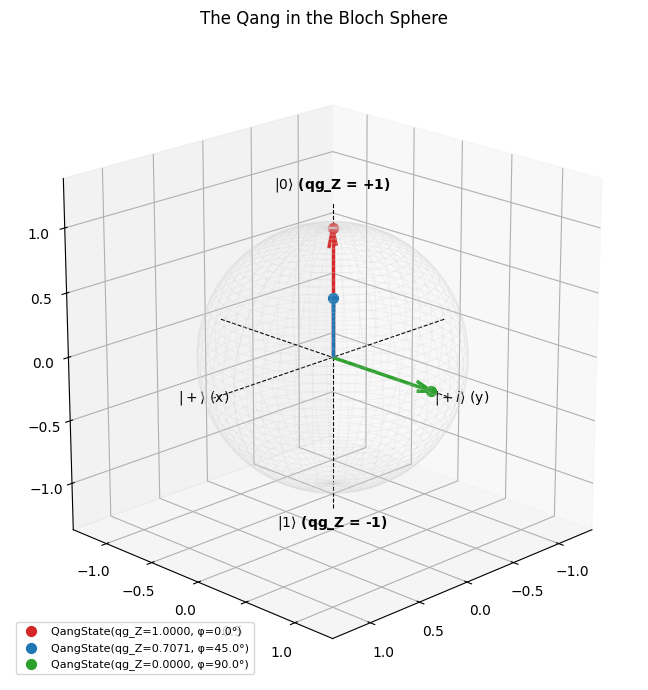

In [11]:
%matplotlib inline
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Funciones base del notebook (por si no estaban en memoria) ---
def qg_z(theta):
    return math.cos(theta)

def theta_from_qg_z(q):
    if not -1.0 <= q <= 1.0:
        raise ValueError(f"qg_Z debe estar en [-1, 1], recibido {q}")
    return math.acos(q)

# --- Clase QangState ---
class QangState:
    """
    Representación en la esfera de Bloch:
    qg_Z = cos(theta) y phi (fase azimutal).
    """
    def __init__(self, qg_z_val: float, phi: float = 0.0):
        if not -1.0 <= qg_z_val <= 1.0:
            raise ValueError(f"qg_Z debe estar en [-1, 1], recibido {qg_z_val}")
        self.qg_z = float(qg_z_val)
        self.phi = float(phi % (2.0 * np.pi))

    @classmethod
    def from_angles(cls, theta: float, phi: float = 0.0):
        return cls(qg_z(theta), phi)

    def to_theta(self):
        return theta_from_qg_z(self.qg_z)

    def to_cartesian(self):
        theta = self.to_theta()
        x = math.sin(theta) * math.cos(self.phi)
        y = math.sin(theta) * math.sin(self.phi)
        z = self.qg_z
        return x, y, z

    def __repr__(self):
        return f"QangState(qg_Z={self.qg_z:.4f}, φ={math.degrees(self.phi):.1f}°)"


# --- Función para graficar ---
def plot_bloch_sphere_native(states, title="The Qang in the Bloch Sphere"):
    if not isinstance(states, list):
        states = [states]

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Malla de la esfera unitaria
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color="lightgray", alpha=0.25, linewidth=0.6)

    # Ejes principales
    ax.plot([-1.2, 1.2], [0, 0], [0, 0], color="black", linestyle="--", linewidth=0.8)
    ax.plot([0, 0], [-1.2, 1.2], [0, 0], color="black", linestyle="--", linewidth=0.8)
    ax.plot([0, 0], [0, 0], [-1.2, 1.2], color="black", linestyle="--", linewidth=0.8)

    # Etiquetas de referencia
    ax.text(0, 0, 1.3, r"$|0\rangle$ (qg_Z = +1)", ha="center", weight="bold")
    ax.text(0, 0, -1.35, r"$|1\rangle$ (qg_Z = -1)", ha="center", weight="bold")
    ax.text(1.3, 0, 0, r"$|+\rangle$ (x)", ha="center")
    ax.text(0, 1.3, 0, r"$|+i\rangle$ (y)", ha="center")

    colors = ["tab:red", "tab:blue", "tab:green", "tab:purple", "tab:orange"]

    # Graficar vectores
    for idx, st in enumerate(states):
        x, y, z = st.to_cartesian()
        c = colors[idx % len(colors)]
        ax.quiver(0, 0, 0, x, y, z, color=c, arrow_length_ratio=0.15, linewidth=2.5)
        ax.scatter([x], [y], [z], color=c, s=50, label=f"{st}")

    ax.set_box_aspect([1, 1, 1])
    ax.set_title(title, pad=20)
    ax.legend(loc="lower left", fontsize=8)
    ax.view_init(elev=20, azim=45)
    plt.tight_layout()
    return fig


# ==========================================================
# LLAMADA DE EJECUCIÓN (Esto es lo que genera y muestra la figura)
# ==========================================================
s_norte = QangState.from_angles(theta=0.0, phi=0.0)
s_t_gate = QangState.from_angles(theta=math.pi / 4, phi=math.pi / 4)
s_plus_i = QangState.from_angles(theta=math.pi / 2, phi=math.pi / 2)

figura = plot_bloch_sphere_native([s_norte, s_t_gate, s_plus_i])
plt.show()

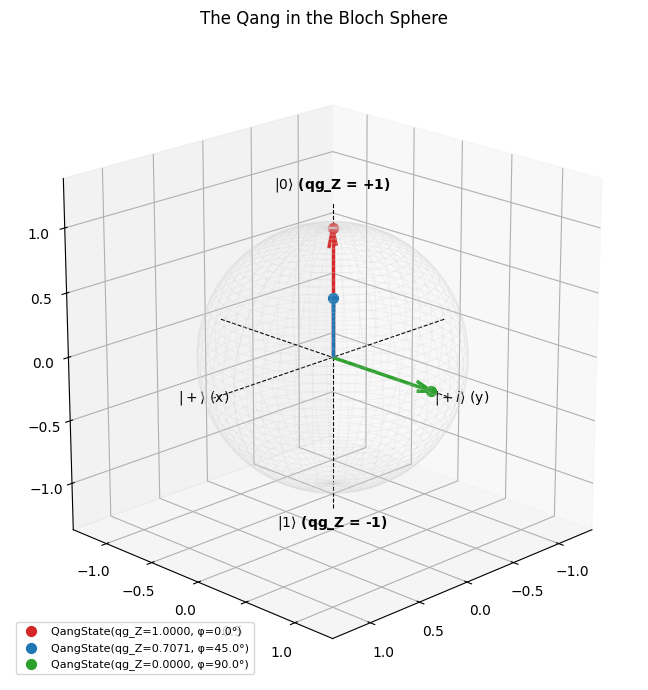

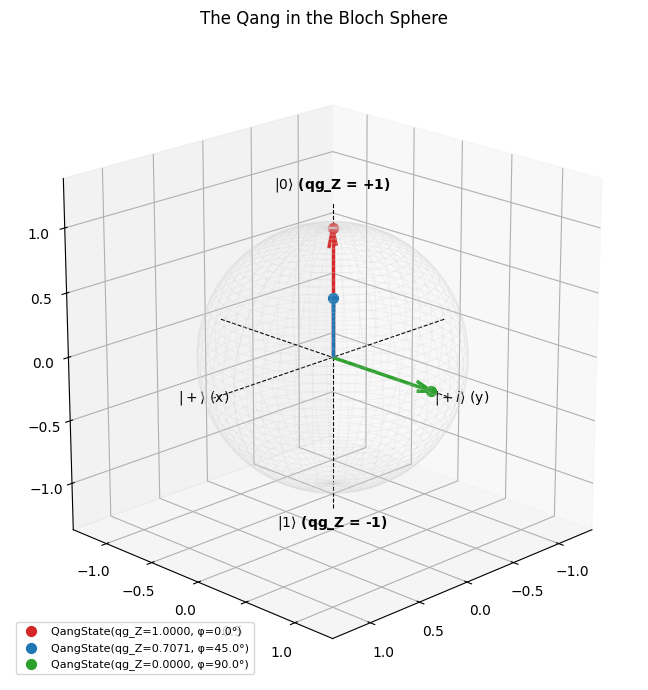

In [12]:
# Crear estados usando los mismos ángulos que tu Sección 3
state_north = QangState.from_angles(theta=0.0, phi=0.0)
state_t_gate = QangState.from_angles(theta=math.pi / 4, phi=math.pi / 4)
state_plus_i = QangState.from_angles(theta=math.pi / 2, phi=math.pi / 2)

plot_bloch_sphere_native([state_north, state_t_gate, state_plus_i])